In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os, cv2, gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2, NASNetMobile
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ Imports loaded")

2026-05-03 06:19:53.197102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777789193.439248      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777789193.504550      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777789194.042864      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777789194.042904      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777789194.042907      57 computation_placer.cc:177] computation placer alr

✅ Imports loaded


In [2]:
FRAMES = 24
IMG_SIZE = 128
BATCH_SIZE = 2

EPOCHS_LRCN = 10
EPOCHS_BASE = 6

LABEL_COLS = ['Engagement','Boredom','Frustration','Confusion']
NUM_CLASSES = 4

DATA_PATH = "/kaggle/input/datasets/olgaparfenova/daisee/DAiSEE"

print("✅ Config set")

✅ Config set


In [3]:
df = pd.read_csv(f"{DATA_PATH}/Labels/TrainLabels.csv")
df.columns = df.columns.str.strip()

print(df.head())

           ClipID  Boredom  Engagement  Confusion  Frustration
0  1100011002.avi        0           2          0            0
1  1100011003.avi        0           2          0            0
2  1100011004.avi        0           3          0            0
3  1100011005.avi        0           3          0            0
4  1100011006.avi        0           3          0            0


In [4]:
video_dict = {}

for root, _, files in os.walk(f"{DATA_PATH}/DataSet"):
    for f in files:
        if f.endswith(".avi"):
            video_dict[f.replace(".avi","")] = os.path.join(root,f)

df['clip'] = df['ClipID'].str.replace(".avi","", regex=False)
df = df[df['clip'].isin(video_dict)]

print("✅ Usable videos:", len(df))

✅ Usable videos: 4852


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

steps_train = len(train_df)//BATCH_SIZE
steps_val   = len(val_df)//BATCH_SIZE

print("Train:", len(train_df))
print("Val  :", len(val_df))

Train: 3881
Val  : 971


In [6]:
def extract_frames(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total < FRAMES:
        cap.release()
        return None

    idx = np.linspace(0, total-1, FRAMES).astype(int)

    frames = []
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ret, frame = cap.read()
        if not ret: continue

        frame = cv2.resize(frame,(IMG_SIZE,IMG_SIZE))
        frame = preprocess_input(frame)
        frames.append(frame)

    cap.release()
    return np.array(frames)

In [17]:
def build_lrcn():
    inp = Input(shape=(FRAMES, IMG_SIZE, IMG_SIZE, 3))

    # ✅ Fix warning by adding input_shape
    base = MobileNetV2(weights='imagenet',
                       include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))

    for layer in base.layers[:-25]:
        layer.trainable = False

    x = TimeDistributed(base)(inp)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    # ✅ Attention
    score = Dense(64, activation='tanh')(x)
    score = Dense(1)(score)
    w = Softmax(axis=1)(score)

    x = Multiply()([x, w])
    x = Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = {
        col.lower(): Dense(4, activation='softmax', name=col.lower())(x)
        for col in LABEL_COLS
    }

    model = Model(inp, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss={col.lower(): 'categorical_crossentropy' for col in LABEL_COLS},
        metrics=['accuracy']
    )

    return model

In [24]:
def build_lrcn():
    inp = Input(shape=(FRAMES, IMG_SIZE, IMG_SIZE, 3))

    base = MobileNetV2(weights='imagenet',
                       include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))

    for layer in base.layers[:-25]:
        layer.trainable = False

    x = TimeDistributed(base)(inp)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    # Attention
    score = Dense(64, activation='tanh')(x)
    score = Dense(1)(score)
    w = Softmax(axis=1)(score)

    x = Multiply()([x, w])
    x = Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = {
        col.lower(): Dense(4, activation='softmax', name=col.lower())(x)
        for col in LABEL_COLS
    }

    model = Model(inp, outputs)

    # ✅ FIXED HERE
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss={col.lower(): 'categorical_crossentropy' for col in LABEL_COLS},
        metrics={col.lower(): 'accuracy' for col in LABEL_COLS}
    )

    return model

In [25]:
def build_gru():
    inp = Input(shape=(FRAMES, IMG_SIZE, IMG_SIZE, 3))

    base = MobileNetV2(weights='imagenet',
                       include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))

    for layer in base.layers[:-30]:
        layer.trainable = False

    x = TimeDistributed(base)(inp)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = GRU(64)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = {
        col.lower(): Dense(4, activation='softmax', name=col.lower())(x)
        for col in LABEL_COLS
    }

    model = Model(inp, outputs)

    # ✅ FIXED HERE
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss={col.lower(): 'categorical_crossentropy' for col in LABEL_COLS},
        metrics={col.lower(): 'accuracy' for col in LABEL_COLS}
    )

    return model

In [26]:
def build_nasnet():
    inp = Input(shape=(FRAMES, IMG_SIZE, IMG_SIZE, 3))

    # Resize for NASNet
    x = TimeDistributed(
        Lambda(lambda img: tf.image.resize(img, (224, 224)))
    )(inp)

    base = NASNetMobile(weights='imagenet',
                        include_top=False,
                        input_shape=(224, 224, 3))

    for layer in base.layers[:-80]:
        layer.trainable = False

    x = TimeDistributed(base)(x)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = LSTM(64)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = {
        col.lower(): Dense(4, activation='softmax', name=col.lower())(x)
        for col in LABEL_COLS
    }

    model = Model(inp, outputs)

    # ✅ FIXED HERE
    model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-4),
        loss={col.lower(): 'categorical_crossentropy' for col in LABEL_COLS},
        metrics={col.lower(): 'accuracy' for col in LABEL_COLS}
    )

    return model

In [27]:
# =======================
# BUILD MODELS
# =======================
lrcn = build_lrcn()
gru  = build_gru()
nas  = build_nasnet()

# =======================
#  TRAIN LRCN
# =======================
print("Training LRCN")

train_gen = generator(train_df)
val_gen   = generator(val_df)

lrcn.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=EPOCHS_LRCN,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

# =======================
#  TRAIN GRU
# =======================
print(" Training GRU")

train_gen = generator(train_df)   #  reset generator
val_gen   = generator(val_df)

gru.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=EPOCHS_BASE
)

# =======================
#  TRAIN NASNET
# =======================
print(" Training NASNet")

train_gen = generator(train_df)   #  reset again
val_gen   = generator(val_df)

nas.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_train // 2,
    validation_steps=steps_val,
    epochs=EPOCHS_BASE
)

Training LRCN
Epoch 1/10


I0000 00:00:1777790481.887749     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


 514/1940 ━━━━━━━━━━━━━━━━━━━━ 10:05 425ms/step - boredom_accuracy: 0.4018 - boredom_loss: 1.2501 - confusion_accuracy: 0.5655 - confusion_loss: 1.0955 - engagement_accuracy: 0.4893 - engagement_loss: 1.0753 - frustration_accuracy: 0.7614 - frustration_loss: 0.8419 - loss: 4.2627

[mpeg4 @ 0x7d62fc0f7680] I cbpy damaged at 16 8
[mpeg4 @ 0x7d62fc0f7680] Error at MB: 344
[mpeg4 @ 0x7d62fc0f7680] I cbpy damaged at 16 8
[mpeg4 @ 0x7d62fc0f7680] Error at MB: 344


1940/1940 ━━━━━━━━━━━━━━━━━━━━ 1170s 540ms/step - boredom_accuracy: 0.4055 - boredom_loss: 1.2165 - confusion_accuracy: 0.6312 - confusion_loss: 0.9873 - engagement_accuracy: 0.4861 - engagement_loss: 1.0051 - frustration_accuracy: 0.7679 - frustration_loss: 0.7773 - loss: 3.9862 - val_boredom_accuracy: 0.4990 - val_boredom_loss: 1.0924 - val_confusion_accuracy: 0.6845 - val_confusion_loss: 0.8201 - val_engagement_accuracy: 0.5320 - val_engagement_loss: 0.8648 - val_frustration_accuracy: 0.7784 - val_frustration_loss: 0.6283 - val_loss: 3.4056
Epoch 2/10
1558/1940 ━━━━━━━━━━━━━━━━━━━━ 2:36 410ms/step - boredom_accuracy: 0.4397 - boredom_loss: 1.1736 - confusion_accuracy: 0.6786 - confusion_loss: 0.8780 - engagement_accuracy: 0.5353 - engagement_loss: 0.8872 - frustration_accuracy: 0.7677 - frustration_loss: 0.6854 - loss: 3.6242

...

970/970 ━━━━━━━━━━━━━━━━━━━━ 1746s 1s/step - boredom_accuracy: 0.3375 - boredom_loss: 1.3234 - confusion_accuracy: 0.6009 - confusion_loss: 1.0257 - engagement_accuracy: 0.4845 - engagement_loss: 1.0362 - frustration_accuracy: 0.7250 - frustration_loss: 0.8391 - loss: 4.2243 - val_boredom_accuracy: 0.4588 - val_boredom_loss: 1.1791 - val_confusion_accuracy: 0.6784 - val_confusion_loss: 0.8989 - val_engagement_accuracy: 0.5196 - val_engagement_loss: 0.9258 - val_frustration_accuracy: 0.7742 - val_frustration_loss: 0.7539 - val_loss: 3.7577
Epoch 2/6
970/970 ━━━━━━━━━━━━━━━━━━━━ 1080s 1s/step - boredom_accuracy: 0.4433 - boredom_loss: 1.1918 - confusion_accuracy: 0.6850 - confusion_loss: 0.8645 - engagement_accuracy: 0.4927 - engagement_loss: 0.9186 - frustration_accuracy: 0.7659 - frustration_loss: 0.6925 - loss: 3.6674 - val_boredom_accuracy: 0.4515 - val_boredom_loss: 1.1568 - val_confusion_accuracy: 0.6825 - val_confusion_loss: 0.8620 - val_engagement_accuracy: 0.5361 - val_engagemen

[mpeg4 @ 0x7d62f8269bc0] I cbpy damaged at 16 8
[mpeg4 @ 0x7d62f8269bc0] Error at MB: 344
[mpeg4 @ 0x7d62f8269bc0] I cbpy damaged at 16 8
[mpeg4 @ 0x7d62f8269bc0] Error at MB: 344


970/970 ━━━━━━━━━━━━━━━━━━━━ 1070s 1s/step - boredom_accuracy: 0.4955 - boredom_loss: 1.0935 - confusion_accuracy: 0.6997 - confusion_loss: 0.7923 - engagement_accuracy: 0.5161 - engagement_loss: 0.8648 - frustration_accuracy: 0.7962 - frustration_loss: 0.6393 - loss: 3.3898 - val_boredom_accuracy: 0.5000 - val_boredom_loss: 1.1033 - val_confusion_accuracy: 0.6918 - val_confusion_loss: 0.8160 - val_engagement_accuracy: 0.5742 - val_engagement_loss: 0.8514 - val_frustration_accuracy: 0.7814 - val_frustration_loss: 0.6338 - val_loss: 3.4045
Epoch 5/6
970/970 ━━━━━━━━━━━━━━━━━━━━ 1066s 1s/step - boredom_accuracy: 0.4866 - boredom_loss: 1.1000 - confusion_accuracy: 0.6977 - confusion_loss: 0.8086 - engagement_accuracy: 0.5572 - engagement_loss: 0.8526 - frustration_accuracy: 0.7653 - frustration_loss: 0.6842 - loss: 3.4455 - val_boredom_accuracy: 0.4825 - val_boredom_loss: 1.0826 - val_confusion_accuracy: 0.6753 - val_confusion_loss: 0.8157 - val_engagement_accuracy: 0.5876 - val_engagemen

[mpeg4 @ 0x7d62f8269bc0] I cbpy damaged at 16 8
[mpeg4 @ 0x7d62f8269bc0] Error at MB: 344
[mpeg4 @ 0x7d62f8269bc0] I cbpy damaged at 16 8
[mpeg4 @ 0x7d62f8269bc0] Error at MB: 344


970/970 ━━━━━━━━━━━━━━━━━━━━ 1072s 1s/step - boredom_accuracy: 0.4914 - boredom_loss: 1.1123 - confusion_accuracy: 0.6852 - confusion_loss: 0.8185 - engagement_accuracy: 0.5433 - engagement_loss: 0.8702 - frustration_accuracy: 0.7787 - frustration_loss: 0.6485 - loss: 3.4495 - val_boredom_accuracy: 0.4825 - val_boredom_loss: 1.0878 - val_confusion_accuracy: 0.6856 - val_confusion_loss: 0.8173 - val_engagement_accuracy: 0.5804 - val_engagement_loss: 0.8435 - val_frustration_accuracy: 0.7804 - val_frustration_loss: 0.6286 - val_loss: 3.3772


In [34]:
def evaluate_model(model, name):
    y_true = {col: [] for col in LABEL_COLS}
    y_pred = {col: [] for col in LABEL_COLS}

    gen = generator(val_df)

    for _ in range(len(val_df)//BATCH_SIZE):
        X, Y = next(gen)
        preds = model.predict(X, verbose=0)

        for col in LABEL_COLS:
            key = col.lower()

            # ✅ FIXED HERE
            y_true[col].extend(np.argmax(Y[key], axis=1))
            y_pred[col].extend(np.argmax(preds[key], axis=1))

    accs = []

    print("\n" + "="*60)
    print(f"📊 {name} RESULTS")
    print("="*60)

    for col in LABEL_COLS:
        acc = accuracy_score(y_true[col], y_pred[col])
        accs.append(acc)

        print(f"\n🔹 {col} Accuracy: {acc*100:.2f}%")

        print(classification_report(
            y_true[col],
            y_pred[col],
            target_names=['Very Low','Low','High','Very High'],
            zero_division=0
        ))

    print(f"\n🔥 Average Accuracy: {np.mean(accs)*100:.2f}%")

    return np.mean(accs)*100, y_true, y_pred

In [35]:
lrcn_acc, y_true_lrcn, y_pred_lrcn = evaluate_model(lrcn, "LRCN")
gru_acc,  y_true_gru,  y_pred_gru  = evaluate_model(gru, "GRU")
nas_acc,  y_true_nas,  y_pred_nas  = evaluate_model(nas, "NASNet")


📊 LRCN RESULTS

🔹 Engagement Accuracy: 58.76%
              precision    recall  f1-score   support

    Very Low       0.00      0.00      0.00         7
         Low       0.00      0.00      0.00        42
        High       0.57      0.71      0.63       479
   Very High       0.61      0.52      0.56       442

    accuracy                           0.59       970
   macro avg       0.30      0.31      0.30       970
weighted avg       0.56      0.59      0.57       970


🔹 Boredom Accuracy: 52.27%
              precision    recall  f1-score   support

    Very Low       0.59      0.69      0.63       436
         Low       0.51      0.31      0.39       298
        High       0.41      0.59      0.49       195
   Very High       0.00      0.00      0.00        41

    accuracy                           0.52       970
   macro avg       0.38      0.40      0.38       970
weighted avg       0.50      0.52      0.50       970


🔹 Frustration Accuracy: 78.04%
              precision

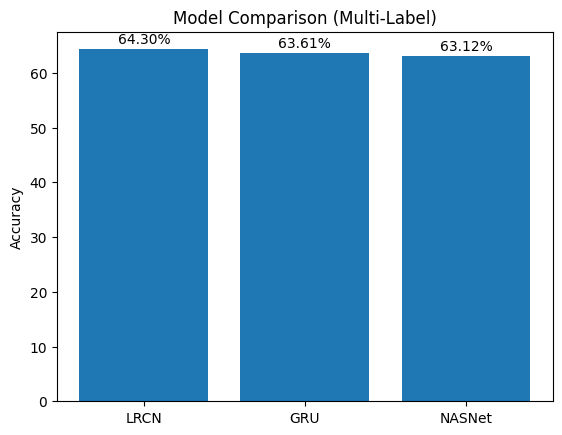

In [36]:
models = ['LRCN','GRU','NASNet']
accs = [lrcn_acc, gru_acc, nas_acc]

plt.figure()
plt.bar(models, accs)
plt.title("Model Comparison (Multi-Label)")
plt.ylabel("Accuracy")

for i,v in enumerate(accs):
    plt.text(i, v+1, f"{v:.2f}%", ha='center')

plt.show()

In [38]:
def plot_confusion(y_true, y_pred, label_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['VL','L','H','VH'],
                yticklabels=['VL','L','H','VH'])

    plt.title(f"{label_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

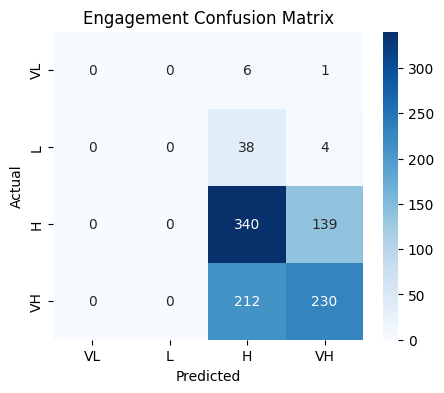

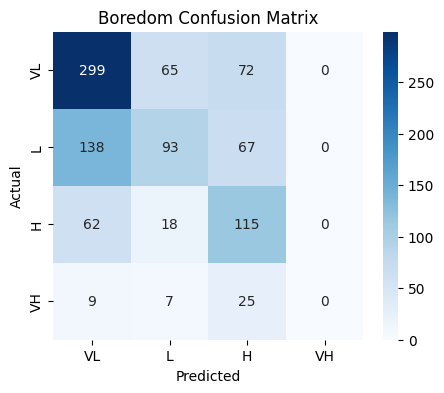

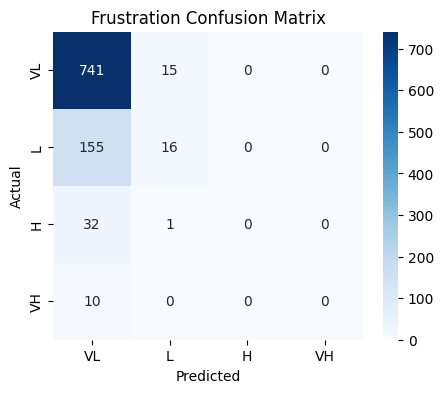

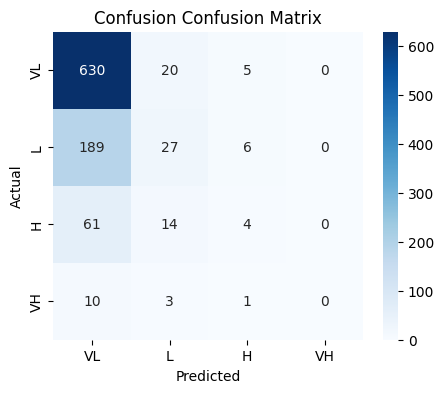

In [39]:
for col in LABEL_COLS:
    plot_confusion(y_true_lrcn[col], y_pred_lrcn[col], col)

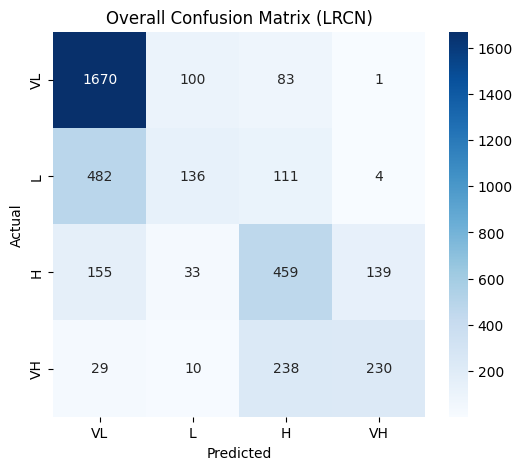

In [59]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all labels
all_true = []
all_pred = []

for col in LABEL_COLS:
    all_true.extend(y_true_lrcn[col])
    all_pred.extend(y_pred_lrcn[col])

# Compute confusion matrix
cm = confusion_matrix(all_true, all_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['VL','L','H','VH'],
            yticklabels=['VL','L','H','VH'])

plt.title("Overall Confusion Matrix (LRCN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
lrcn.save("/kaggle/working/lrcn_model.h5")
gru.save("/kaggle/working/gru_model.h5")
nas.save("/kaggle/working/nasnet_model.h5")

print(" Models saved")

 Models saved


In [41]:
print("\n✅ FINAL MODEL COMPARISON")
print(f"LRCN Avg Accuracy  : {lrcn_acc:.2f}%")
print(f"GRU Avg Accuracy   : {gru_acc:.2f}%")
print(f"NASNet Avg Accuracy: {nas_acc:.2f}%")


✅ FINAL MODEL COMPARISON
LRCN Avg Accuracy  : 64.30%
GRU Avg Accuracy   : 63.61%
NASNet Avg Accuracy: 63.12%


In [43]:
for col in LABEL_COLS:
    print(f"\n {col} Comparison")
    print(f"LRCN  : {accuracy_score(y_true_lrcn[col], y_pred_lrcn[col])*100:.2f}%")
    print(f"GRU   : {accuracy_score(y_true_gru[col],  y_pred_gru[col])*100:.2f}%")
    print(f"NASNet: {accuracy_score(y_true_nas[col],  y_pred_nas[col])*100:.2f}%")


 Engagement Comparison
LRCN  : 58.76%
GRU   : 57.84%
NASNet: 58.04%

 Boredom Comparison
LRCN  : 52.27%
GRU   : 51.44%
NASNet: 48.25%

 Frustration Comparison
LRCN  : 78.04%
GRU   : 78.87%
NASNet: 77.84%

 Confusion Comparison
LRCN  : 68.14%
GRU   : 66.29%
NASNet: 68.35%


In [53]:
def predict_with_actual(model, row):
    path = video_dict[row['clip']]
    frames = extract_frames(path)

    if frames is None:
        print("❌ Skipped video")
        return

    X = np.expand_dims(frames, axis=0)
    preds = model.predict(X, verbose=0)

    labels = ['Very Low','Low','High','Very High']

    print("\n🎯 ACTUAL vs PREDICTED")
    print("="*40)

    for col in LABEL_COLS:
        key = col.lower()

        actual = labels[row[col]]
        pred   = labels[np.argmax(preds[key][0])]

        print(f"{col}:")
        print(f"   Actual   → {actual}")
        print(f"   Predicted→ {pred}")

In [51]:
import cv2
import matplotlib.pyplot as plt

def show_video_frames(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idx = np.linspace(0, total-1, num_frames).astype(int)

    plt.figure(figsize=(15,3))

    for i, frame_id in enumerate(idx):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()
        if not ret:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.subplot(1, num_frames, i+1)
        plt.imshow(frame)
        plt.axis('off')
        plt.title(f"Frame {frame_id}")

    cap.release()
    plt.show()

🎥 Clip: 1100011021


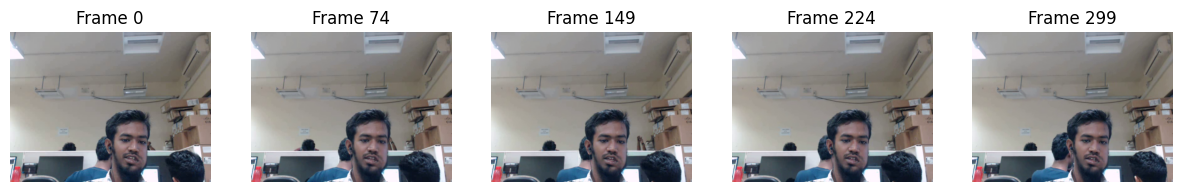


🎯 ACTUAL vs PREDICTED
Engagement:
   Actual   → Very High
   Predicted→ Very High
Boredom:
   Actual   → Very Low
   Predicted→ Very Low
Frustration:
   Actual   → Very Low
   Predicted→ Very Low
Confusion:
   Actual   → Very Low
   Predicted→ Very Low


In [54]:
sample_row = val_df.sample(1).iloc[0]
video_path = video_dict[sample_row['clip']]

print("🎥 Clip:", sample_row['clip'])

show_video_frames(video_path)

predict_with_actual(lrcn, sample_row)


🎥 Clip: 3100702048


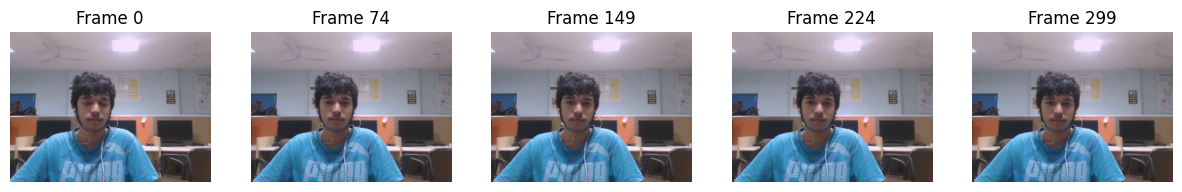


🎯 ACTUAL vs PREDICTED
Engagement:
   Actual   → Very High
   Predicted→ High
Boredom:
   Actual   → Very Low
   Predicted→ Very Low
Frustration:
   Actual   → Very Low
   Predicted→ Very Low
Confusion:
   Actual   → Very Low
   Predicted→ Very Low

🎥 Clip: 3100722057


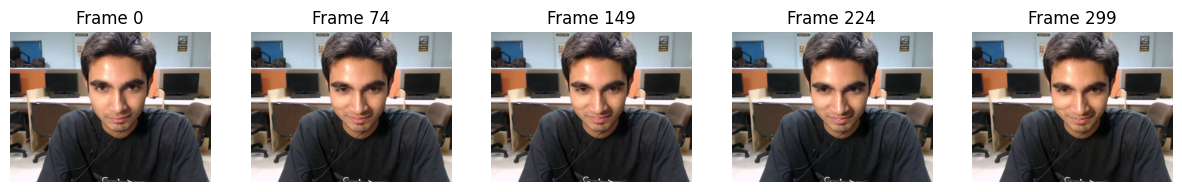


🎯 ACTUAL vs PREDICTED
Engagement:
   Actual   → Very High
   Predicted→ Very High
Boredom:
   Actual   → Very Low
   Predicted→ Very Low
Frustration:
   Actual   → Very Low
   Predicted→ Very Low
Confusion:
   Actual   → Very Low
   Predicted→ Very Low

🎥 Clip: 2100612024


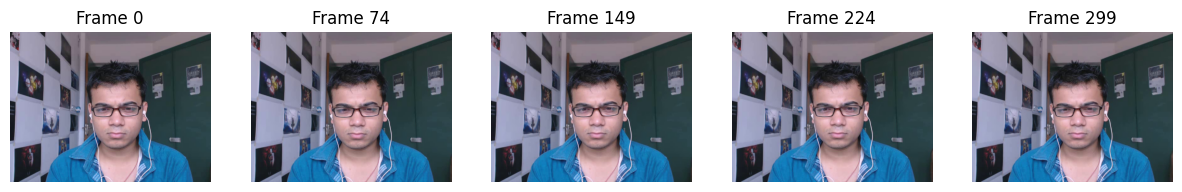


🎯 ACTUAL vs PREDICTED
Engagement:
   Actual   → Very High
   Predicted→ Very High
Boredom:
   Actual   → Very Low
   Predicted→ Very Low
Frustration:
   Actual   → Low
   Predicted→ Very Low
Confusion:
   Actual   → Very Low
   Predicted→ Very Low


In [55]:
for _ in range(3):
    sample_row = val_df.sample(1).iloc[0]
    video_path = video_dict[sample_row['clip']]

    print("\n🎥 Clip:", sample_row['clip'])
    show_video_frames(video_path)
    predict_with_actual(lrcn, sample_row)

In [56]:
print("\n FINAL RESULTS")
print("="*40)
print(f"LRCN Accuracy  : {lrcn_acc:.2f}%")
print(f"GRU Accuracy   : {gru_acc:.2f}%")
print(f"NASNet Accuracy: {nas_acc:.2f}%")


 FINAL RESULTS
LRCN Accuracy  : 64.30%
GRU Accuracy   : 63.61%
NASNet Accuracy: 63.12%


In [58]:
lrcn.save("/kaggle/working/best_lrcn_model.h5")
print("✅ Model saved")

✅ Model saved


In [60]:
import pandas as pd
from sklearn.metrics import classification_report

def get_report_table(y_true, y_pred):
    all_true, all_pred = [], []

    for col in LABEL_COLS:
        all_true.extend(y_true[col])
        all_pred.extend(y_pred[col])

    report = classification_report(
        all_true,
        all_pred,
        target_names=['Very Low','Low','High','Very High'],
        output_dict=True,
        zero_division=0
    )

    df = pd.DataFrame(report).transpose()

    # Keep only needed columns
    df = df[['precision','recall','f1-score']]

    # Rename for clean display
    df.columns = ['P','R','F1']

    return df

In [61]:
lrcn_table = get_report_table(y_true_lrcn, y_pred_lrcn)
gru_table  = get_report_table(y_true_gru,  y_pred_gru)
nas_table  = get_report_table(y_true_nas,  y_pred_nas)

print("LRCN Results")
display(lrcn_table)

print("\nGRU Results")
display(gru_table)

print("\nNASNet Results")
display(nas_table)

LRCN Results


,P,R,F1
Very Low,0.714897,0.900755,0.797136
Low,0.487455,0.185539,0.268775
High,0.515152,0.583969,0.547406
Very High,0.614973,0.453649,0.522134
accuracy,0.643041,0.643041,0.643041
macro avg,0.583119,0.530978,0.533863
weighted avg,0.618408,0.643041,0.610795



GRU Results


,P,R,F1
Very Low,0.710371,0.909336,0.797633
Low,0.423237,0.138776,0.209016
High,0.511186,0.582166,0.544372
Very High,0.600536,0.441815,0.509091
accuracy,0.636082,0.636082,0.636082
macro avg,0.561332,0.518023,0.515028
weighted avg,0.601327,0.636082,0.597186



NASNet Results


,P,R,F1
Very Low,0.709747,0.893031,0.790909
Low,0.447699,0.145380,0.219487
High,0.496250,0.505732,0.500946
Very High,0.570312,0.574803,0.572549
accuracy,0.631186,0.631186,0.631186
macro avg,0.556002,0.529737,0.520973
weighted avg,0.598588,0.631186,0.595261


In [62]:
final_table = pd.concat(
    [lrcn_table, gru_table, nas_table],
    axis=1,
    keys=['LRCN','GRU','NASNet']
)

display(final_table)

LRCN                           GRU                      \
                     P         R        F1         P         R        F1   
Very Low      0.714897  0.900755  0.797136  0.710371  0.909336  0.797633   
Low           0.487455  0.185539  0.268775  0.423237  0.138776  0.209016   
High          0.515152  0.583969  0.547406  0.511186  0.582166  0.544372   
Very High     0.614973  0.453649  0.522134  0.600536  0.441815  0.509091   
accuracy      0.643041  0.643041  0.643041  0.636082  0.636082  0.636082   
macro avg     0.583119  0.530978  0.533863  0.561332  0.518023  0.515028   
weighted avg  0.618408  0.643041  0.610795  0.601327  0.636082  0.597186   

                NASNet                      
                     P         R        F1  
Very Low      0.709747  0.893031  0.790909  
Low           0.447699  0.145380  0.219487  
High          0.496250  0.505732  0.500946  
Very High     0.570312  0.574803  0.572549  
accuracy      0.631186  0.631186  0.631186  
macro avg     0.556002  0.529737  0.520973  
weighted avg  0.598588  0.631186  0.595261